# MLP Baseline — Drug-Drug Interaction Prediction

Baseline model using only molecular fingerprints (no graph structure) for DDI prediction on OGB-DDI. Establishes the performance achievable from molecular features alone, isolating the contribution of graph topology when compared against GNN models (GraphSAGE, GAT).

Architecture: Morgan Fingerprints (2048 bits) -> Linear Encoder (128 dim) -> Element-wise product of drug pair embeddings -> 3-layer MLP predictor -> Sigmoid -> Interaction probability.

Explainability: Integrated Gradients attributes predictions to specific fingerprint bits, mapped back to molecular substructures via RDKit.

Biological validation: CYP enzyme overlap analysis using parsed DrugBank XML data (academic license). Same 5 drug pairs as GAT notebook for cross-model comparison.

Dataset: OGB-DDI (4,267 drugs, 2.1M interactions). Evaluation: AUC-ROC, Hits@20 (OGB evaluator), Precision, Recall, F1.

## Set up

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive/ddi_capstone'):
    for f in files:
        if 'lookup' in f.lower() or 'drugbank' in f.lower() or 'ogb_lookup' in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/ddi_capstone/drug_bank_parsing/drugbank_clean.csv
/content/drive/MyDrive/ddi_capstone/drug_bank_parsing/drug_lookup_raw.pkl
/content/drive/MyDrive/ddi_capstone/drug_bank_parsing/drugbank_clean.parquet
/content/drive/MyDrive/ddi_capstone/drug_bank_parsing/drugbank_validation.py
/content/drive/MyDrive/ddi_capstone/drug_bank_parsing/ogb_lookup.pkl
/content/drive/MyDrive/ddi_capstone/drug_bank_parsing/ogb_drug_lookup.json


In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'torch_geometric', 'ogb', 'rdkit'], check=True)

CompletedProcess(args=['pip', 'install', '-q', 'torch_geometric', 'ogb', 'rdkit'], returncode=0)

In [ ]:
subprocess.run(['pip', 'install', '-q', 'torch_geometric', 'ogb', 'rdkit'], check=True)

import torch
import torch.nn as nn
import torch.nn.functional as F
from ogb.linkproppred import PygLinkPropPredDataset, Evaluator
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import numpy as np
import pandas as pd
import json
import os
import pickle
import subprocess
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# PyTorch 2.6 c
from torch_geometric.data.storage import GlobalStorage
from torch_geometric.data.data import DataEdgeAttr, DataTensorAttr, Data
from torch_geometric.data import HeteroData
torch.serialization.add_safe_globals([GlobalStorage, DataEdgeAttr, DataTensorAttr, Data, HeteroData])
_original_load = torch.load
torch.load = lambda *args, **kwargs: _original_load(*args, **{**kwargs, 'weights_only': False})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


## Loading the data

In [ ]:
# Load OGB-DDI dataset, molecular fingerprints, and DrugBank annotations.
# ogb_lookup contains CYP enzymes, transporters, and targets per drug,
# parsed from the full DrugBank XML using our academic license.

dataset = PygLinkPropPredDataset(name='ogbl-ddi')
split_edge = dataset.get_edge_split()
graph = dataset[0]
edge_index = graph.edge_index.to(device)
num_nodes = graph.num_nodes

# Fingerprints from molecular preprocessing
fingerprints = torch.load('/content/drive/MyDrive/ddi_capstone/molecular/data/fingerprints.pt')
print(f"Nodes: {num_nodes}, Fingerprint dim: {fingerprints.shape[1]}")

# DrugBank lookup for biological validation
with open('/content/drive/MyDrive/ddi_capstone/drug_bank_parsing/ogb_lookup.pkl', 'rb') as f:
    ogb_lookup = pickle.load(f)

cyp_count = sum(1 for v in ogb_lookup.values() if len(v.get('cyp_enzymes', [])) > 0)
print(f"DrugBank lookup: {len(ogb_lookup)} drugs, {cyp_count} with CYP data")

# Output directory
save_dir = '/content/drive/MyDrive/ddi_capstone/MLP_baseline/models'
plot_dir = '/content/drive/MyDrive/ddi_capstone/MLP_baseline/plots'
os.makedirs(save_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

Downloaded 0.04 GB: 100%|██████████| 46/46 [00:06<00:00,  7.13it/s]


Extracting dataset/ddi.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00,  9.14it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 472.12it/s]

Saving...



Done!


Nodes: 4267, Fingerprint dim: 2048
DrugBank lookup: 4267 drugs, 514 with CYP data


In [ ]:
# Data Splits & Evaluation Setup
# ================================
# OGB-DDI provides official train/valid/test splits for reproducibility:
#   - Train: ~1.8M positive edges (the graph the model sees)
#   - Valid/Test: ~160K positive + ~160K negative edges each
#
# Negative edges (non-interacting drug pairs) for valid/test come from OGB.
# Training negatives are sampled on-the-fly per batch (torch.randint),
# following the standard OGB protocol — this prevents the model from
# memorizing specific negatives and improves generalization.
#
# Evaluator uses Hits@20: for each positive edge, rank it against all
# negatives and check if it appears in the top 20. This is the official
# OGB-DDI metric alongside AUC-ROC.

train_pos = split_edge['train']['edge'].to(device)
val_pos = split_edge['valid']['edge'].to(device)
val_neg = split_edge['valid']['edge_neg'].to(device)
test_pos = split_edge['test']['edge'].to(device)
test_neg = split_edge['test']['edge_neg'].to(device)

evaluator = Evaluator(name='ogbl-ddi')

print(f"Train: {train_pos.shape}")
print(f"Val pos: {val_pos.shape}, Val neg: {val_neg.shape}")
print(f"Test pos: {test_pos.shape}, Test neg: {test_neg.shape}")

Train: torch.Size([1067911, 2])
Val pos: torch.Size([133489, 2]), Val neg: torch.Size([101882, 2])
Test pos: torch.Size([133489, 2]), Test neg: torch.Size([95599, 2])


## MLP baseline

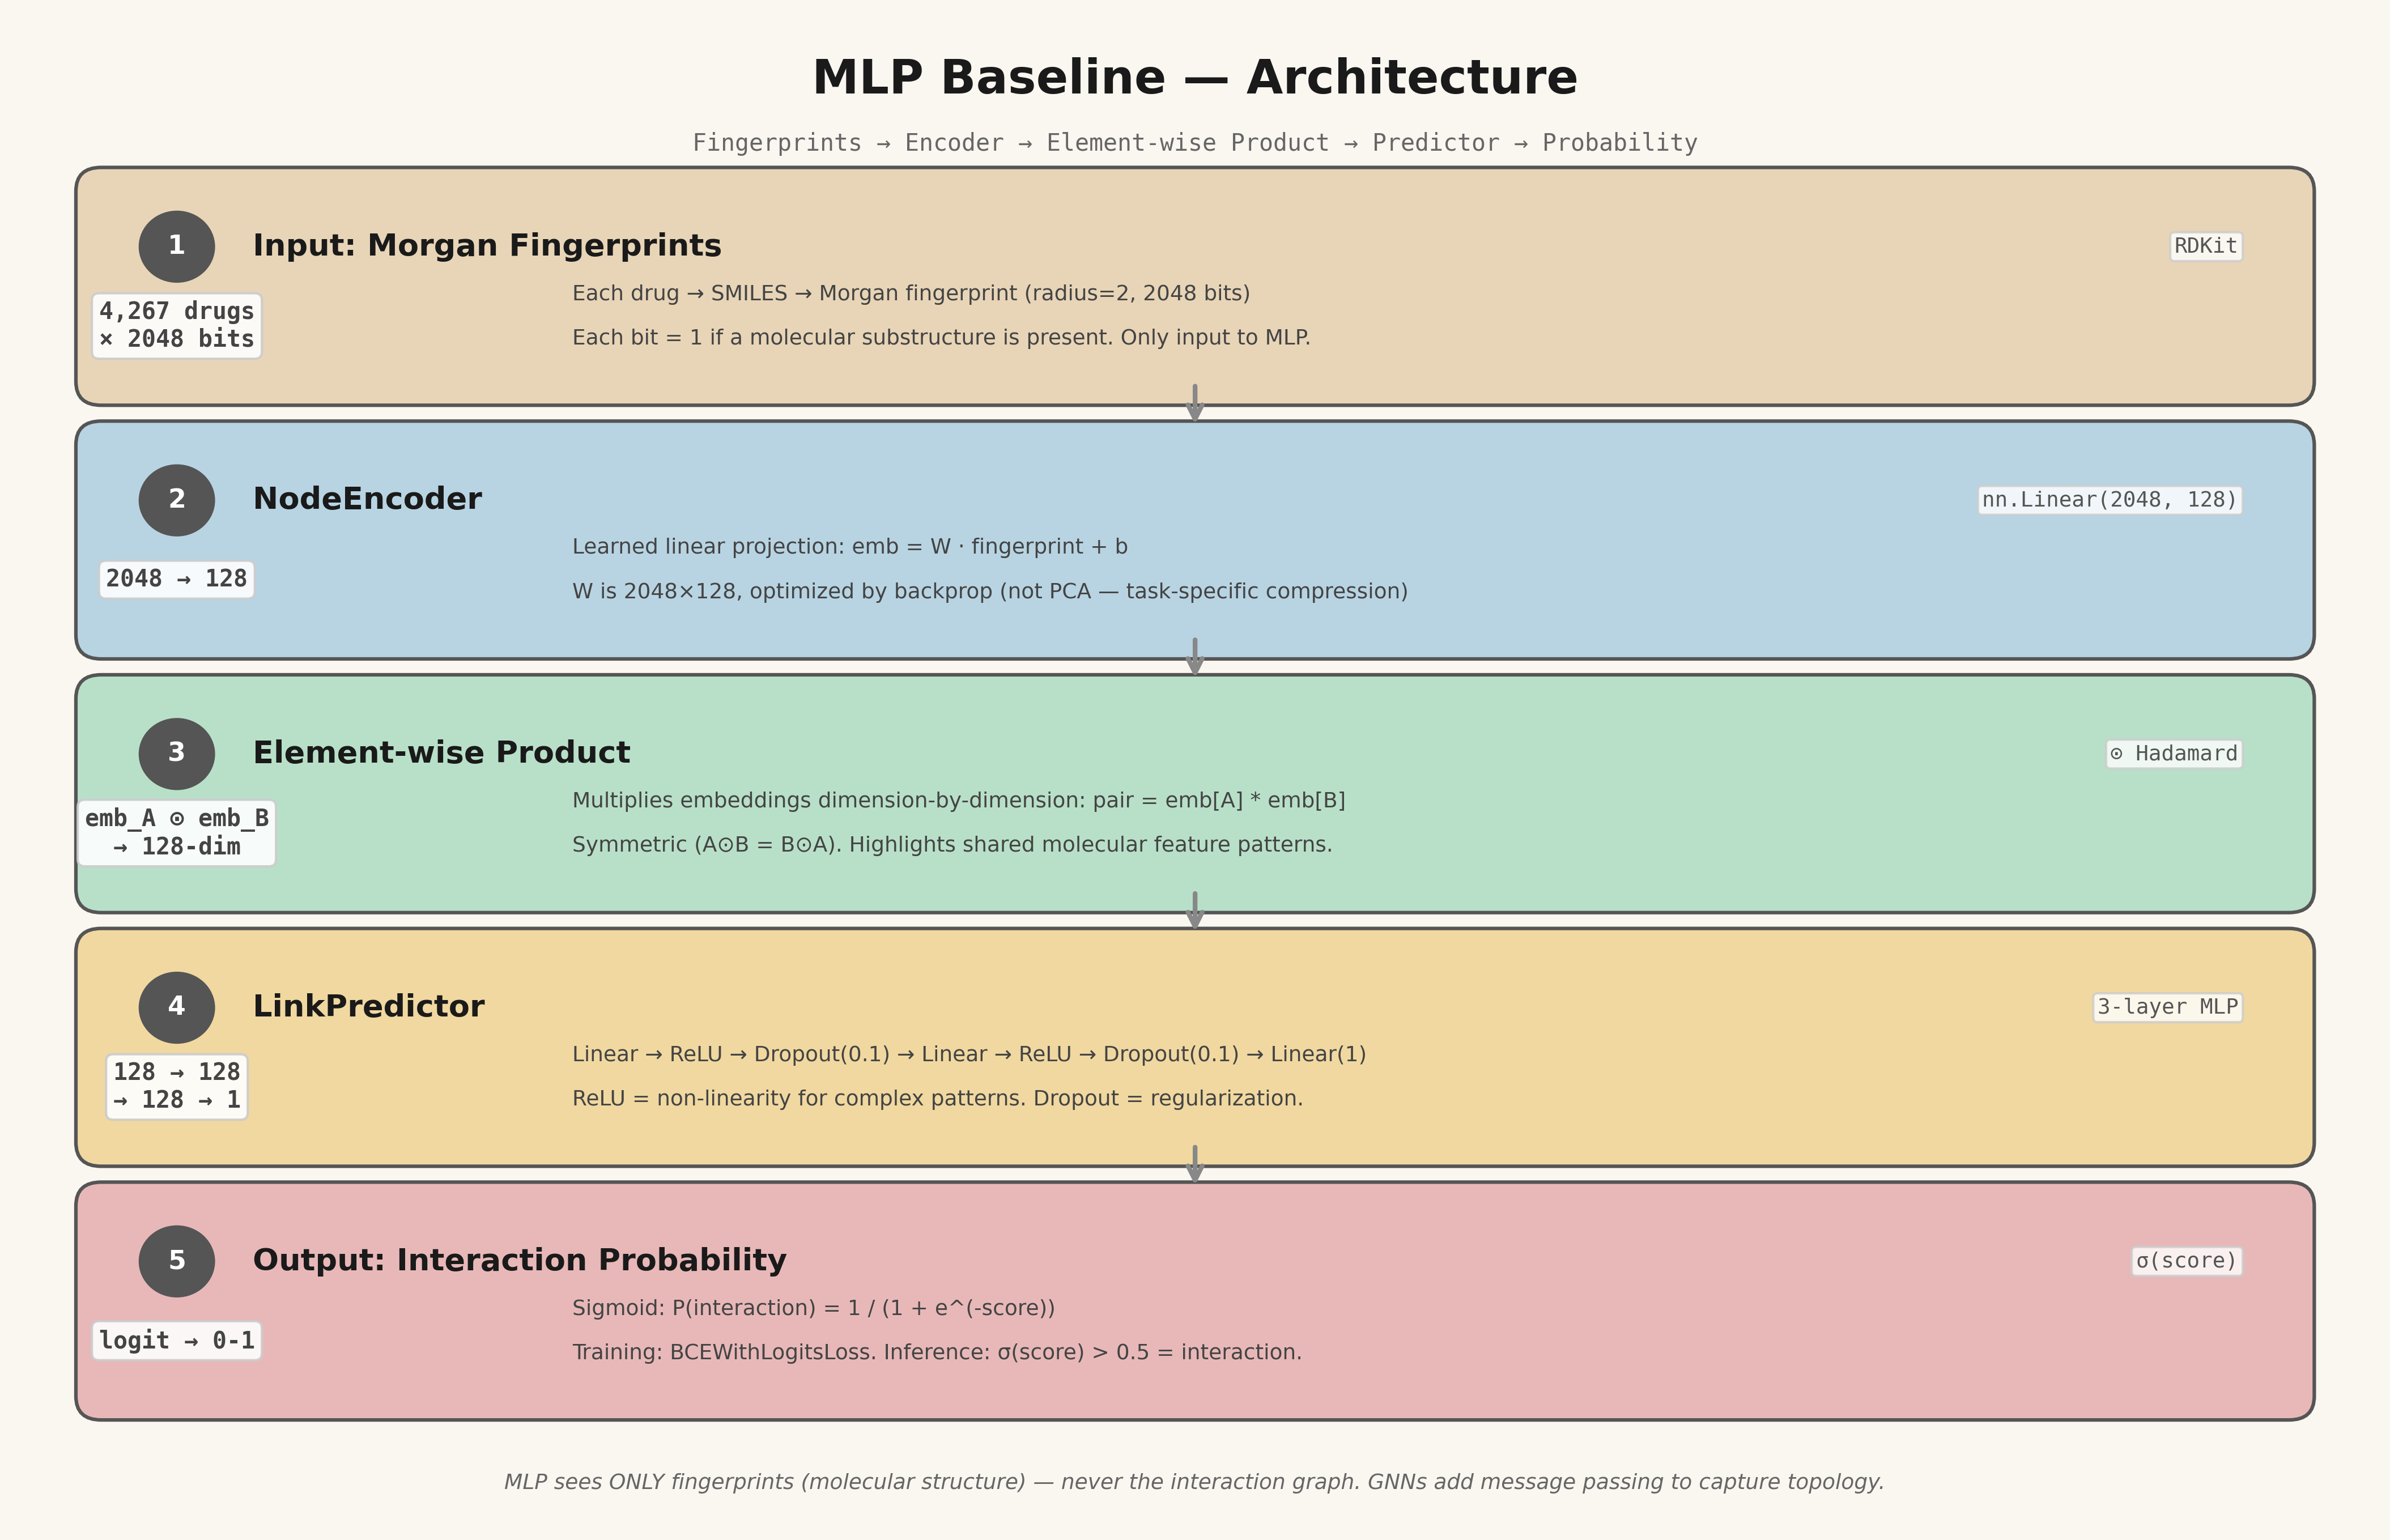

In [ ]:
# MLP Baseline Architecture
# =========================
# No message passing, no graph structure — this is the key constraint.
# The MLP sees ONLY molecular fingerprints, never the interaction graph.
# This isolates what can be learned from molecular structure alone,
# so when GNNs outperform it, the delta = graph topology contribution.
#
# Pipeline: Morgan Fingerprints (2048 bits)
#        -> NodeEncoder: Linear projection to 128-dim embeddings
#        -> Element-wise product: emb[drug_A] * emb[drug_B]
#           (captures shared feature patterns between the pair)
#        -> LinkPredictor: 3-layer MLP with ReLU + Dropout
#        -> Sigmoid -> interaction probability
#
# Why element-wise product? It's symmetric (A*B = B*A, order doesn't
# matter for DDI) and highlights dimensions where both drugs have
# strong signals — analogous to detecting shared molecular features.

import random
import numpy as np
import torch
import torch.nn as nn

# Fix random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_osis_all(42)


class NodeEncoder(nn.Module):
    """Projects 2048-bit Morgan fingerprints to 128-dim dense embeddings.

    Args:
        input_dim (int): Input fingerprint dimension (2048).
        hidden_dim (int): Output embedding dimension (128).
    """
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)

    def forward(self, x):
        """
        Args:
            x: Tensor of shape (num_drugs, input_dim)
        Returns:
            Tensor of shape (num_drugs, hidden_dim)
        """
        return self.encoder(x)


class LinkPredictor(nn.Module):
    """3-layer MLP that scores drug pairs from element-wise product.
    Hidden -> ReLU -> Dropout -> Hidden -> ReLU -> Dropout -> Output.

    Args:
        hidden_dim (int): Input and hidden layer dimension.
        num_layers (int): Total number of linear layers.
        dropout (float): Dropout probability applied after each hidden layer.
    """
    def __init__(self, hidden_dim, num_layers, dropout):
        super().__init__()
        layers = []
        for i in range(num_layers):
            if i < num_layers - 1:
                layers.extend([
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.ReLU(),
                    nn.Dropout(dropout)
                ])
            else:
                layers.append(nn.Linear(hidden_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        """
        Args:
            x: Tensor of shape (num_edges, hidden_dim) — element-wise products
        Returns:
            Tensor of shape (num_edges,) — raw interaction scores (pre-sigmoid)
        """
        return self.mlp(x).squeeze(-1)


class MLPBaseline(nn.Module):
    """Full MLP pipeline: fingerprints -> encoder -> element-wise product -> predictor.

    Serves as the fingerprint-only baseline. By excluding graph topology,
    any performance gap relative to GNNs quantifies the contribution of
    the interaction network structure to DDI prediction.

    Args:
        input_dim (int): Morgan fingerprint dimension (2048).
        hidden_dim (int): Embedding and hidden layer dimension (128).
        num_layers (int): Number of layers in the LinkPredictor.
        dropout (float): Dropout probability.
    """
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.encoder = NodeEncoder(input_dim, hidden_dim)
        self.predictor = LinkPredictor(hidden_dim, num_layers, dropout)

    def encode(self, fingerprints):
        """
        Args:
            fingerprints: Tensor of shape (num_drugs, input_dim)
        Returns:
            Tensor of shape (num_drugs, hidden_dim)
        """
        return self.encoder(fingerprints)

    def decode(self, emb, edge):
        """Element-wise product of drug pair embeddings passed to predictor.

        Args:
            emb: Tensor of shape (num_drugs, hidden_dim)
            edge: Tensor of shape (2, num_edges) — drug pair indices
        Returns:
            Tensor of shape (num_edges,) — raw interaction scores
        """
        # Element-wise product: symmetric combination (A*B = B*A)
        # highlights dimensions where both drugs have strong signals
        return self.predictor(emb[edge[0]] * emb[edge[1]])

    def forward(self, fingerprints, edge):
        """End-to-end forward pass from fingerprints to interaction scores.

        Args:
            fingerprints: Tensor of shape (num_drugs, input_dim)
            edge: Tensor of shape (2, num_edges) — drug pair indices
        Returns:
            Tensor of shape (num_edges,) — raw scores (pre-sigmoid)
        """
        emb = self.encode(fingerprints)
        return self.decode(emb, edge)


# Hyperparameters — consistent with GraphSAGE and GAT
# The comparison focuses on WHAT each architecture captures,
# not parameter count.
config = {
    'input_dim': 2048,      # Morgan fingerprint bits
    'hidden_dim': 128,      # Same as GraphSAGE for fair comparison
    'num_layers': 3,        # Same depth across MLP and GraphSAGE
    'dropout': 0.1,
    'lr': 0.001,
    'batch_size': 1024,
    'num_epochs': 30,
    'patience': 10,         # Early stopping (not triggered in 30 epochs)
}

model = MLPBaseline(
    config['input_dim'], config['hidden_dim'],
    config['num_layers'], config['dropout']
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Config: {config}")

Total parameters: 295,425
Config: {'input_dim': 2048, 'hidden_dim': 128, 'num_layers': 3, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 1024, 'num_epochs': 30, 'patience': 10}


### Training

In [ ]:

# Training Loop
# =============
# Loss: BCEWithLogitsLoss (binary cross-entropy with built-in sigmoid)
#   - Positive pairs (real interactions): target = 1
#   - Negative pairs (random drug pairs): target = 0
#   - Total loss = pos_loss + neg_loss (equal weight)
#
# Negative sampling: on-the-fly per batch via torch.randint.
#   - Each epoch sees DIFFERENT negatives → prevents memorization
#   - Random pairs in a sparse graph (~2.1M of ~9M possible) are
#     overwhelmingly true negatives
#   - This improved AUC from 0.879 (fixed negatives) to 0.969
#
# Optimization:
#   - Adam (lr=0.001): adaptive learning rate per parameter
#   - Gradient clipping (max_norm=1.0): prevents exploding gradients
#   - Early stopping (patience=10): stops if val AUC doesn't improve
#     for 10 epochs (not triggered in 30 epochs — model kept improving)
#
# Evaluation per epoch:
#   - Val loss: same BCE as training, on OGB's fixed val negatives
#   - AUC-ROC: discrimination between positive and negative pairs
#   - Hits@20: OGB official metric — for each positive edge, rank it
#     against all negatives, check if it's in the top 20
#
# Checkpointing: saves best model by val AUC to Google Drive

fp = fingerprints.to(device)
train_loader = DataLoader(torch.arange(train_pos.shape[0]), batch_size=config['batch_size'], shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_hits20': []}
best_auc = 0
patience_counter = 0

for epoch in range(config['num_epochs']):
    # --- Training phase ---
    model.train()
    total_loss = 0
    num_batches = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['num_epochs']}")
    for batch_idx in pbar:
        optimizer.zero_grad()

        # Get positive edges for this batch
        pos_edge = train_pos[batch_idx].t()
        emb = model.encode(fp)

        # Score real interactions (should be high)
        pos_score = model.predictor(emb[pos_edge[0]] * emb[pos_edge[1]])

        # Generate random negative pairs on-the-fly (should score low)
        neg_edge = torch.randint(0, num_nodes, pos_edge.shape, device=device)
        neg_score = model.predictor(emb[neg_edge[0]] * emb[neg_edge[1]])

        # BCE loss: push positives toward 1, negatives toward 0
        pos_loss = F.binary_cross_entropy_with_logits(pos_score, torch.ones_like(pos_score))
        neg_loss = F.binary_cross_entropy_with_logits(neg_score, torch.zeros_like(neg_score))
        loss = pos_loss + neg_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Prevent exploding gradients
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1
        pbar.set_postfix({'loss': f'{total_loss/num_batches:.4f}'})

    avg_loss = total_loss / num_batches
    history['train_loss'].append(avg_loss)

    # --- Validation phase (no gradients, fixed OGB negatives) ---
    model.eval()
    with torch.no_grad():
        emb = model.encode(fp)
        val_pos_score = model.predictor(emb[val_pos[:, 0]] * emb[val_pos[:, 1]])
        val_neg_score = model.predictor(emb[val_neg[:, 0]] * emb[val_neg[:, 1]])

        # Validation loss
        vl_pos = F.binary_cross_entropy_with_logits(val_pos_score, torch.ones_like(val_pos_score))
        vl_neg = F.binary_cross_entropy_with_logits(val_neg_score, torch.zeros_like(val_neg_score))
        val_loss = (vl_pos + vl_neg).item()
        history['val_loss'].append(val_loss)

        # Hits@20 via OGB evaluator (official benchmark metric)
        hits_result = evaluator.eval({
            'y_pred_pos': val_pos_score.view(-1),
            'y_pred_neg': val_neg_score.view(-1),
        })
        val_hits20 = hits_result['hits@20']
        history['val_hits20'].append(float(val_hits20))

        # AUC-ROC (how well model separates positives from negatives)
        pos_probs = torch.sigmoid(val_pos_score).cpu().numpy()
        neg_probs = torch.sigmoid(val_neg_score).cpu().numpy()
        y_true = np.concatenate([np.ones(len(pos_probs)), np.zeros(len(neg_probs))])
        y_scores = np.concatenate([pos_probs.flatten(), neg_probs.flatten()])
        val_auc = roc_auc_score(y_true, y_scores)
        history['val_auc'].append(val_auc)

    print(f"Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_loss={val_loss:.4f}, "
          f"val_auc={val_auc:.4f}, val_hits20={val_hits20:.4f}")

    # --- Early stopping and checkpointing ---
    if val_auc > best_auc:
        best_auc = val_auc
        patience_counter = 0
        torch.save({
            'model': model.state_dict(),
            'epoch': epoch,
            'auc': val_auc,
            'hits20': float(val_hits20),
        }, f'{save_dir}/best_model.pt')
        print(f"  -> New best model saved (AUC: {val_auc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= config['patience']:
            print(f"  -> Early stopping at epoch {epoch+1}")
            break

# Save training history
with open(f'{save_dir}/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f"\nTraining complete. Best val AUC: {best_auc:.4f}")

Epoch 1/30: 100%|██████████| 1043/1043 [00:14<00:00, 71.51it/s, loss=1.0024] 


Epoch 1: train_loss=1.0024, val_loss=0.7764, val_auc=0.9148, val_hits20=0.0284
  -> New best model saved (AUC: 0.9148)


Epoch 2/30: 100%|██████████| 1043/1043 [00:09<00:00, 109.16it/s, loss=0.8484]


Epoch 2: train_loss=0.8484, val_loss=0.6883, val_auc=0.9345, val_hits20=0.0253
  -> New best model saved (AUC: 0.9345)


Epoch 3/30: 100%|██████████| 1043/1043 [00:08<00:00, 120.66it/s, loss=0.8055]


...

Epoch 28: train_loss=0.7019, val_loss=0.5123, val_auc=0.9698, val_hits20=0.1592
  -> New best model saved (AUC: 0.9698)


Epoch 29/30: 100%|██████████| 1043/1043 [00:08<00:00, 116.68it/s, loss=0.7023]


Epoch 29: train_loss=0.7023, val_loss=0.5064, val_auc=0.9698, val_hits20=0.1489
  -> New best model saved (AUC: 0.9698)


Epoch 30/30: 100%|██████████| 1043/1043 [00:09<00:00, 108.38it/s, loss=0.7007]


Epoch 30: train_loss=0.7007, val_loss=0.5101, val_auc=0.9696, val_hits20=0.0771

Training complete. Best val AUC: 0.9698


### Testing

In [ ]:
# Test Evaluation — MLP Baseline
# ================================
# Loads the best checkpoint (by val AUC) and evaluates on the held-out
# test set. Metrics: AUC-ROC (discrimination), Hits@20 (ranking, OGB
# standard), Precision, Recall, F1 (classification at threshold=0.5).
# Threshold 0.5 is appropriate given balanced positive/negative sampling.

try:
    ckpt = torch.load(f'{save_dir}/best_model.pt', map_location=device)
except FileNotFoundError:
    raise FileNotFoundError(
        f"No checkpoint found at '{save_dir}/best_model.pt'. "
        "Run training cell first."
    )

model.load_state_dict(ckpt['model'])
model.eval()

print(f"Loaded best model from epoch {ckpt['epoch']+1} (val AUC: {ckpt['auc']:.4f})")

with torch.no_grad():
    emb = model.encode(fp)
    test_pos_score = model.predictor(emb[test_pos[:, 0]] * emb[test_pos[:, 1]])
    test_neg_score = model.predictor(emb[test_neg[:, 0]] * emb[test_neg[:, 1]])

    # Hits@20: OGB standard ranking metric
    hits_result = evaluator.eval({
        'y_pred_pos': test_pos_score.view(-1),
        'y_pred_neg': test_neg_score.view(-1),
    })
    test_hits20 = hits_result['hits@20']

    # Classification metrics at threshold=0.5
    pos_probs = torch.sigmoid(test_pos_score).cpu().numpy()
    neg_probs = torch.sigmoid(test_neg_score).cpu().numpy()
    y_true = np.concatenate([np.ones(len(pos_probs)), np.zeros(len(neg_probs))])
    y_scores = np.concatenate([pos_probs.flatten(), neg_probs.flatten()])
    y_pred = (y_scores > 0.5).astype(int)

    test_auc = roc_auc_score(y_true, y_scores)
    test_precision = precision_score(y_true, y_pred, zero_division=0)
    test_recall = recall_score(y_true, y_pred, zero_division=0)
    test_f1 = f1_score(y_true, y_pred, zero_division=0)

print("=" * 60)
print("TEST SET RESULTS - MLP Baseline")
print("=" * 60)
print(f"AUC-ROC:    {test_auc:.4f}")
print(f"Hits@20:    {test_hits20:.4f}")
print(f"Precision:  {test_precision:.4f}")
print(f"Recall:     {test_recall:.4f}")
print(f"F1-Score:   {test_f1:.4f}")

# Persist results for cross-model comparison table
test_results = {
    'auc': test_auc, 'hits20': float(test_hits20),
    'precision': test_precision, 'recall': test_recall, 'f1': test_f1,
}
try:
    with open(f'{save_dir}/test_results.json', 'w') as f:
        json.dump(test_results, f, indent=2)
    print(f"\nResults saved to {save_dir}/test_results.json")
except OSError as e:
    print(f"Warning: could not save results — {e}")

Loaded best model from epoch 29 (val AUC: 0.9698)
TEST SET RESULTS - MLP Baseline
AUC-ROC:    0.9693
Hits@20:    0.0803
Precision:  0.9391
Recall:     0.8594
F1-Score:   0.8975

Results saved to /content/drive/MyDrive/ddi_capstone/MLP_baseline/models/test_results.json


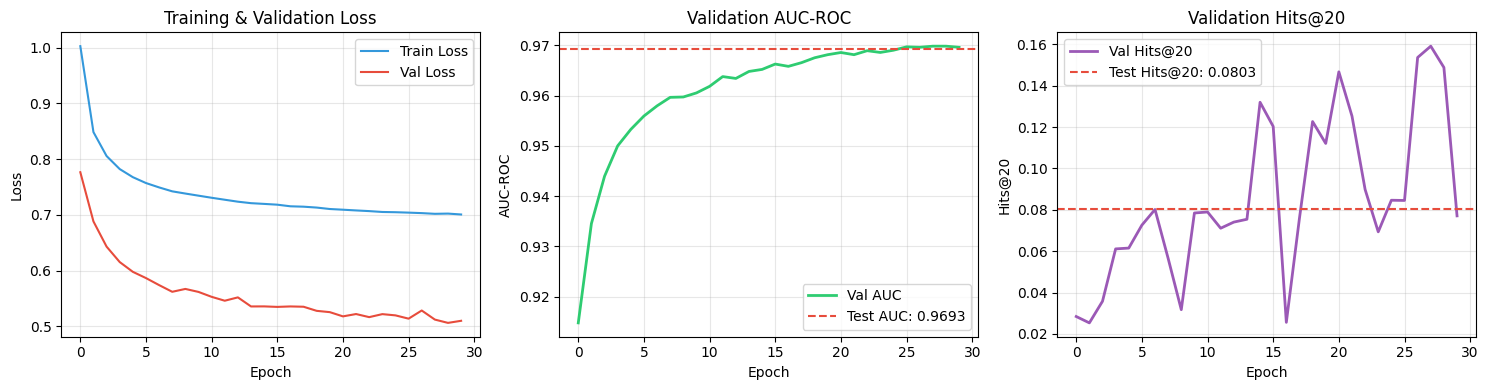

Saved to /content/drive/MyDrive/ddi_capstone/MLP_baseline/plots/training_curves.png


In [ ]:
# Training Curves — MLP Baseline
# ================================
# Visualises loss convergence and metric progression over epochs.
# Red dashed lines mark final test performance for reference.
# Divergence between train/val loss indicates overfitting;
# plateau in AUC signals early stopping trigger point.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train Loss', color='#3498db')
axes[0].plot(history['val_loss'], label='Val Loss', color='#e74c3c')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_auc'], label='Val AUC', color='#2ecc71', linewidth=2)
axes[1].axhline(y=test_auc, color='#e74c3c', linestyle='--', label=f'Test AUC: {test_auc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Validation AUC-ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_hits20'], label='Val Hits@20', color='#9b59b6', linewidth=2)
axes[2].axhline(y=float(test_hits20), color='#e74c3c', linestyle='--', label=f'Test Hits@20: {test_hits20:.4f}')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Hits@20')
axes[2].set_title('Validation Hits@20')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

try:
    plt.savefig(f'{plot_dir}/training_curves.png', dpi=150, bbox_inches='tight')
    print(f"Saved to {plot_dir}/training_curves.png")
except OSError as e:
    print(f"Warning: could not save figure — {e}")

plt.show()

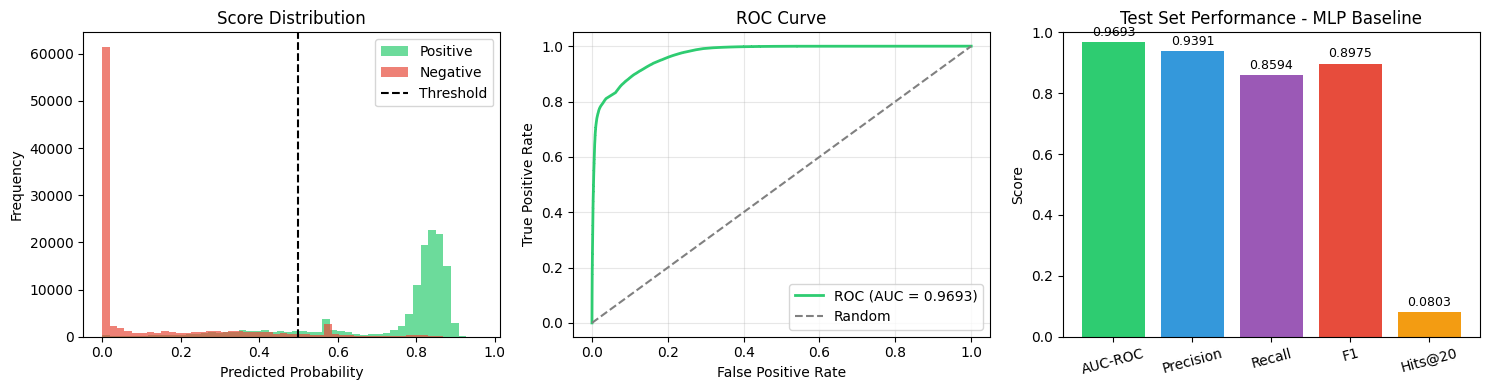

Saved to /content/drive/MyDrive/ddi_capstone/MLP_baseline/plots/test_evaluation.png


In [ ]:
# Score distribution and ROC curve
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Score distribution
axes[0].hist(pos_probs, bins=50, alpha=0.7, label='Positive', color='#2ecc71')
axes[0].hist(neg_probs, bins=50, alpha=0.7, label='Negative', color='#e74c3c')
axes[0].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Score Distribution')
axes[0].legend()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2ecc71', linewidth=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# Metrics bar chart
metrics = ['AUC-ROC', 'Precision', 'Recall', 'F1', 'Hits@20']
values = [test_auc, test_precision, test_recall, test_f1, float(test_hits20)]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12']
bars = axes[2].bar(metrics, values, color=colors)
axes[2].set_ylim(0, 1.0)
axes[2].set_ylabel('Score')
axes[2].set_title('Test Set Performance - MLP Baseline')
for bar, v in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.4f}', ha='center', fontsize=9)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{plot_dir}/test_evaluation.png', dpi=150)
plt.show()
print(f"Saved to {plot_dir}/test_evaluation.png")

# Biological validations

In [ ]:
# Load the full parsed DrugBank biological annotations.
# These tables were generated in the drugbank parsing notebook and contain
# enzymes, targets, and transporters for all 4,267 OGB-DDI drugs.
import pandas as pd
from collections import defaultdict
import os

drugbank_path = '/content/drive/MyDrive/ddi_capstone/full_drugbank_parsing'

df_enz = pd.read_csv(os.path.join(drugbank_path, 'ogb_drug_enzymes.csv'))
df_tgt = pd.read_csv(os.path.join(drugbank_path, 'ogb_drug_targets.csv'))
df_trn = pd.read_csv(os.path.join(drugbank_path, 'ogb_drug_transporters.csv'))

def build_lookup(df, entity_col, idx_col='ogb_idx'):
    """Create a dictionary mapping OGB index to set of biological entities."""
    lookup = defaultdict(set)
    for _, row in df.iterrows():
        idx = int(row[idx_col])
        entity = row[entity_col]
        if pd.notna(entity):
            lookup[idx].add(entity)
    return dict(lookup)

enzyme_lookup = build_lookup(df_enz, 'enzyme_name')
target_lookup = build_lookup(df_tgt, 'target_name')
transporter_lookup = build_lookup(df_trn, 'transporter_name')

print(f"Biological annotation coverage:")
print(f"  Enzymes:      {len(enzyme_lookup)} drugs")
print(f"  Targets:      {len(target_lookup)} drugs")
print(f"  Transporters: {len(transporter_lookup)} drugs")

Biological annotation coverage:
  Enzymes:      1638 drugs
  Targets:      3067 drugs
  Transporters: 966 drugs


In [ ]:
# Biological Validation Framework
# ================================
# Goal: test whether the model's predictions align with known pharmacology.
# If the model is capturing real biology, its top-predicted drug pairs should
# share more biological entities (CYP enzymes, targets, transporters) than
# random drug pairs.
#
# Method: Fisher's exact test (2×2 contingency table)
#   - Compares overlap rates: predicted pairs vs random baseline
#   - One-sided test (alternative='greater'): we hypothesize predicted > random
#   - Returns odds ratio (effect size) and p-value (significance)
#
#   Contingency table:
#                    | Shared entity | No shared entity |
#   Predicted pairs  |      a        |        b         |
#   Random pairs     |      c        |        d         |
#
#   Odds ratio > 1 → predicted pairs share more biology than random
#   p < 0.05 → statistically significant enrichment
#
# Why Fisher's exact test? Works well with small sample sizes (unlike chi-square),
# which is important because only ~12% of OGB-DDI drugs have CYP annotations
# in DrugBank (514 of 4,267).
#
# This is the same validation framework used across all models (MLP, GraphSAGE, GAT)
# to enable fair cross-model comparison of biological interpretability.

from scipy.stats import fisher_exact

def compute_biological_overlap(pairs, lookup):
    """For a list of (idx_a, idx_b) pairs, compute how many share at least
    one entity from the given lookup (e.g., CYP enzymes, targets).
    Only counts pairs where BOTH drugs have annotations — avoids bias
    from unannotated drugs inflating the denominator."""
    n_overlap = 0
    n_annotated = 0
    details = []
    for idx_a, idx_b in pairs:
        set_a = lookup.get(idx_a, set())
        set_b = lookup.get(idx_b, set())
        if len(set_a) > 0 and len(set_b) > 0:
            n_annotated += 1
            shared = set_a & set_b
            if len(shared) > 0:
                n_overlap += 1
                details.append((idx_a, idx_b, shared))
    rate = n_overlap / n_annotated if n_annotated > 0 else 0
    return n_overlap, n_annotated, rate, details

def biological_validation(predicted_pairs, random_pairs, lookup, entity_name):
    """Compare biological overlap between predicted and random pairs.
    Uses one-sided Fisher's exact test to assess whether predicted pairs
    share significantly more biological entities than random.

    Returns dict with overlap counts, rates, odds ratio, and p-value."""
    pred_overlap, pred_ann, pred_rate, pred_details = compute_biological_overlap(
        predicted_pairs, lookup
    )
    rand_overlap, rand_ann, rand_rate, rand_details = compute_biological_overlap(
        random_pairs, lookup
    )
    # Build 2x2 contingency table for Fisher's test
    a = pred_overlap                # predicted pairs WITH shared entity
    b = pred_ann - pred_overlap     # predicted pairs WITHOUT shared entity
    c = rand_overlap                # random pairs WITH shared entity
    d = rand_ann - rand_overlap     # random pairs WITHOUT shared entity
    if pred_ann > 0 and rand_ann > 0:
        odds_ratio, p_value = fisher_exact([[a, b], [c, d]], alternative='greater')
    else:
        odds_ratio, p_value = float('nan'), float('nan')
    return {
        'entity_type': entity_name,
        'pred_overlap': pred_overlap,
        'pred_annotated': pred_ann,
        'pred_rate': pred_rate,
        'rand_overlap': rand_overlap,
        'rand_annotated': rand_ann,
        'rand_rate': rand_rate,
        'odds_ratio': odds_ratio,
        'p_value': p_value,
        'pred_details': pred_details,
    }

def generate_random_pairs(n_pairs, num_nodes, seed=42):
    """Generate random drug pairs as baseline for comparison.
    Uses min/max ordering to avoid duplicates (A,B) = (B,A)."""
    rng = np.random.RandomState(seed)
    pairs = set()
    while len(pairs) < n_pairs:
        a, b = rng.randint(0, num_nodes, size=2)
        if a != b:
            pairs.add((min(a, b), max(a, b)))
    return list(pairs)

print("Validation functions defined.")

Validation functions defined.


In [ ]:
import torch

save_dir = '/content/drive/MyDrive/ddi_capstone/MLP_baseline/models'
# Load the trained model checkpoint instead of retraining
ckpt = torch.load(f'{save_dir}/best_model.pt')
model.load_state_dict(ckpt['model'])
model.eval()
print(f"Loaded best model from epoch {ckpt['epoch']+1} (val AUC: {ckpt['auc']:.4f})")

Loaded best model from epoch 29 (val AUC: 0.9698)


In [ ]:
fingerprints = torch.load('/content/drive/MyDrive/ddi_capstone/molecular/data/fingerprints.pt')

In [ ]:
fp = fingerprints.to(device)

In [ ]:
# Biological Validation — MLP Baseline
# ======================================
# Scores all positive test pairs, selects the top-200 by predicted probability,
# and compares their biological overlap against 200 random drug pairs.
#
# Why top-200? Large enough to estimate overlap rates reliably given that only
# ~12% of OGB-DDI drugs have DrugBank annotations, while small enough to
# represent genuinely high-confidence predictions rather than the full test set.
# Note: GNN models use top-5000 due to larger annotated neighborhoods;
# equal-K comparison is a documented future work item.

try:
    model.eval()
    with torch.no_grad():
        emb = model.encode(fp)
        test_pos_scores = torch.sigmoid(
            model.predictor(emb[test_pos[:, 0]] * emb[test_pos[:, 1]])
        ).cpu().numpy()
except NameError as e:
    raise RuntimeError(
        f"Required variable not found: {e}. "
        "Ensure fingerprints (fp) and test_pos are loaded before running this cell."
    )

top_k = 200
top_indices = np.argsort(test_pos_scores.flatten())[-top_k:]
top_pairs = [(int(test_pos[i, 0]), int(test_pos[i, 1])) for i in top_indices]
random_pairs = generate_random_pairs(top_k, num_nodes, seed=42)

print(f"Top {top_k} predicted pairs (score range: "
      f"{test_pos_scores[top_indices[0]]:.4f} - {test_pos_scores[top_indices[-1]]:.4f})")
print(f"Random baseline: {len(random_pairs)} pairs\n")

validation_results = {}
for lookup, name in [(enzyme_lookup, 'Enzymes'),
                      (target_lookup, 'Targets'),
                      (transporter_lookup, 'Transporters')]:
    validation_results[name] = biological_validation(
        top_pairs, random_pairs, lookup, name
    )

print(f"{'='*75}")
print(f"BIOLOGICAL VALIDATION - MLP Baseline (top {top_k} test pairs vs random)")
print(f"{'='*75}")
print(f"{'Entity':<15} | {'Predicted':>18} | {'Random':>18} | {'OR':>6} | {'p-value':>8}")
print("-" * 75)

for name, r in validation_results.items():
    pred_str = f"{r['pred_overlap']}/{r['pred_annotated']} ({r['pred_rate']:.1%})"
    rand_str = f"{r['rand_overlap']}/{r['rand_annotated']} ({r['rand_rate']:.1%})"
    or_str = f"{r['odds_ratio']:.2f}" if not np.isnan(r['odds_ratio']) else "N/A"
    p_str = f"{r['p_value']:.4f}" if not np.isnan(r['p_value']) else "N/A"
    print(f"{name:<15} | {pred_str:>18} | {rand_str:>18} | {or_str:>6} | {p_str:>8}")

print(f"\nFisher's exact test (one-sided, greater)")
print(f"p < 0.05 = predicted pairs share significantly more biology than random")

Top 200 predicted pairs (score range: 0.9077 - 0.9658)
Random baseline: 200 pairs

BIOLOGICAL VALIDATION - MLP Baseline (top 200 test pairs vs random)
Entity          |          Predicted |             Random |     OR |  p-value
---------------------------------------------------------------------------
Enzymes         |      41/59 (69.5%) |       8/25 (32.0%) |   4.84 |   0.0016
Targets         |      12/200 (6.0%) |        4/99 (4.0%) |   1.52 |   0.3408
Transporters    |      18/25 (72.0%) |        4/7 (57.1%) |   1.93 |   0.3756

Fisher's exact test (one-sided, greater)
p < 0.05 = predicted pairs share significantly more biology than random


In [ ]:
# Check annotation coverage in the top predicted pairs and random pairs
top_pair_nodes = set([p[0] for p in top_pairs] + [p[1] for p in top_pairs])
rand_pair_nodes = set([p[0] for p in random_pairs] + [p[1] for p in random_pairs])

for name, lookup in [('Enzymes', enzyme_lookup), ('Targets', target_lookup), ('Transporters', transporter_lookup)]:
    top_both = sum(1 for a, b in top_pairs if a in lookup and b in lookup)
    rand_both = sum(1 for a, b in random_pairs if a in lookup and b in lookup)
    print(f"{name}: top pairs with both annotated = {top_both}, random = {rand_both}")

Enzymes: top pairs with both annotated = 59, random = 25
Targets: top pairs with both annotated = 200, random = 99
Transporters: top pairs with both annotated = 25, random = 7


Biological Validation Summary — MLP Baseline
**The MLP baseline shows statistically significant enzyme overlap (p=0.0016, OR=4.84) in its top predicted pairs: 69.5% of annotated pairs share at least one metabolic enzyme compared to 32.0% in random pairs**. **This confirms that molecular fingerprints encode structural signals related to shared metabolic pathways, particularly CYP enzymes, which are a primary mechanism of pharmacokinetic drug-drug interactions.**
**Target overlap (6.0% vs 4.0%, p=0.34) is not significant, indicating that molecular structure alone does not reliably predict shared protein targets. This is expected since target-mediated interactions are functional relationships not fully captured by structural similarity. GNN models, which incorporate graph topology from the interaction network, should improve on this by encoding pharmacological relationships beyond molecular structure.**
Transporter overlap (72.0% vs 57.1%, p=0.38) shows a trend but lacks statistical power due to low annotation coverage (25 and 7 annotated pairs respectively).
These findings establish the MLP as a meaningful baseline: it captures metabolism-driven interactions through structural features but cannot detect target-mediated or pathway-level interactions that require graph context. This motivates the use of GNN architectures (GraphSAGE, GAT) which leverage neighborhood information to capture these higher-order biological signals.

# EXAI

In [ ]:
# Drug Pair Selection for Integrated Gradients Case Studies
# =========================================================
# We select 5 pairs from the top-200 highest-scoring predictions for
# detailed explainability analysis. These same 5 pairs are used across
# ALL models (MLP, GraphSAGE, GAT) for direct cross-model comparison.
#
# Selection criteria:
#   1. Both drugs must have SMILES strings (needed for IG → atom mapping)
#   2. Both drugs must have enzyme annotations in DrugBank (needed for
#      biological validation — can we connect IG results to known mechanisms?)
#   3. Prioritize pairs with shared CYP enzymes (most interpretable DDI mechanism)
#
# Sorting: by number of shared enzymes first, then prediction score.
# This gives us pairs where we can validate whether IG highlights
# substructures involved in the shared metabolic pathway.
#
# Important limitation: IG tells us WHICH substructures matter, but not
# WHY they matter. The biological context (CYP overlap, targets) comes
# from DrugBank, not from the model itself. GNNs address this gap through
# perturbation analysis, where important neighbors directly reveal
# pharmacological mechanisms (see explainability ladder below).

drug_mapping = pd.read_csv('/content/drive/MyDrive/ddi_capstone/molecular/data/drug_mapping_smiles.csv')
idx_to_smiles = dict(zip(drug_mapping['node idx'], drug_mapping['smiles']))

df_info = pd.read_csv(os.path.join(drugbank_path, 'ogb_drug_info.csv'))
idx_to_name = dict(zip(df_info['ogb_idx'], df_info['name']))

candidates = []
for i, (idx_a, idx_b) in enumerate(top_pairs):
    smiles_a = idx_to_smiles.get(idx_a)
    smiles_b = idx_to_smiles.get(idx_b)
    enz_a = enzyme_lookup.get(idx_a, set())
    enz_b = enzyme_lookup.get(idx_b, set())
    tgt_a = target_lookup.get(idx_a, set())
    tgt_b = target_lookup.get(idx_b, set())

    has_smiles = pd.notna(smiles_a) and pd.notna(smiles_b)
    shared_enz = enz_a & enz_b
    shared_tgt = tgt_a & tgt_b
    score = float(test_pos_scores[top_indices[-(i+1)]])

    if has_smiles and len(enz_a) > 0 and len(enz_b) > 0:
        candidates.append({
            'idx_a': idx_a, 'idx_b': idx_b,
            'name_a': idx_to_name.get(idx_a, f'Drug_{idx_a}'),
            'name_b': idx_to_name.get(idx_b, f'Drug_{idx_b}'),
            'score': score,
            'shared_enzymes': shared_enz,
            'shared_targets': shared_tgt,
            'n_shared_enz': len(shared_enz),
            'n_shared_tgt': len(shared_tgt),
        })

# Prioritize pairs with most shared enzymes, then highest score
candidates.sort(key=lambda x: (x['n_shared_enz'], x['score']), reverse=True)

print(f"Candidates with SMILES + enzyme data: {len(candidates)}")
print(f"\nTop 10 candidates:")
for i, c in enumerate(candidates[:10]):
    print(f"  {i+1}. {c['name_a']} + {c['name_b']}")
    print(f"     Score: {c['score']:.4f} | Shared enzymes: {c['n_shared_enz']} | Shared targets: {c['n_shared_tgt']}")
    if c['shared_enzymes']:
        print(f"     Enzymes: {', '.join(sorted(c['shared_enzymes']))}")

Candidates with SMILES + enzyme data: 59

Top 10 candidates:
  1. Terfenadine + Alprazolam
     Score: 0.9576 | Shared enzymes: 3 | Shared targets: 0
     Enzymes: Cytochrome P450 3A4, Cytochrome P450 3A5, Cytochrome P450 3A7
  2. Nilotinib + Dacomitinib
     Score: 0.9259 | Shared enzymes: 3 | Shared targets: 0
     Enzymes: Cytochrome P450 2C9, Cytochrome P450 2D6, Cytochrome P450 3A4
  3. Palonosetron + Clomipramine
     Score: 0.9258 | Shared enzymes: 3 | Shared targets: 0
     Enzymes: Cytochrome P450 1A2, Cytochrome P450 2D6, Cytochrome P450 3A4
  4. Midostaurin + Mestranol
     Score: 0.9126 | Shared enzymes: 3 | Shared targets: 0
     Enzymes: Cytochrome P450 2C8, Cytochrome P450 2C9, Cytochrome P450 3A4
  5. Alfentanil + Alprazolam
     Score: 0.9097 | Shared enzymes: 3 | Shared targets: 0
     Enzymes: Cytochrome P450 3A4, Cytochrome P450 3A5, Cytochrome P450 3A7
  6. Flunitrazepam + Alprazolam
     Score: 0.9658 | Shared enzymes: 2 | Shared targets: 3
     Enzymes: Cytochrom

## Explainability Ladder: From Substructures to Mechanisms

Integrated Gradients on the MLP reveals **what** molecular substructures drive a prediction — which fingerprint bits (and their corresponding atoms) contribute most to the interaction score. However, IG cannot explain **why** those substructures matter pharmacologically. The biological context (shared CYP enzymes, overlapping targets) must be supplied externally from DrugBank.

This represents the first rung of an explainability ladder that our cross-model comparison builds upon:

**Level 1 — MLP + Integrated Gradients**: identifies important molecular substructures. Useful for medicinal chemistry (which functional groups matter?) but silent on interaction mechanisms. Requires external knowledge to connect structure → pharmacology.

**Level 2 — GraphSAGE + Perturbation Analysis**: identifies important graph neighbors. Since neighbors are drugs that share interactions, perturbation reveals which drugs in the network most influence the prediction — and when those neighbors share CYP enzymes with the target pair, the explanation directly maps to metabolic competition mechanisms.

**Level 3 — GAT + Attention Weights + Perturbation**: adds learned attention over neighbors. Attention weights show how the model weighs different neighbors during message passing, while perturbation validates which neighbors actually impact predictions. The low concordance between these methods (~3.5%) shows they capture complementary aspects of model reasoning — attention reflects learned aggregation patterns, perturbation reflects causal importance.

Each architecture level adds interpretive depth. The MLP establishes a structural baseline; GNNs connect structure to pharmacological mechanisms through graph topology. This progression from "what substructures" to "which pathways" to "how the model reasons about neighbors" directly addresses the explainability gap identified by Abbas et al. (2025) and Ru et al. (2025), who noted that current DDI prediction models function as black boxes despite high predictive accuracy.

In [ ]:
# Select 5 pairs for detailed IG case studies from the top candidates.
# Chosen for diversity in CYP enzyme families and biological mechanisms.
selected_pairs = candidates[:5]
# Add pair 6 and 7 which also have shared targets
selected_pairs = [candidates[0], candidates[1], candidates[2], candidates[5], candidates[6]]

print("Selected pairs for IG analysis:")
for i, c in enumerate(selected_pairs):
    print(f"\n  {i+1}. {c['name_a']} + {c['name_b']}")
    print(f"     Score: {c['score']:.4f}")
    print(f"     Shared enzymes ({c['n_shared_enz']}): {', '.join(sorted(c['shared_enzymes']))}")
    if c['shared_targets']:
        print(f"     Shared targets ({c['n_shared_tgt']}): {', '.join(sorted(c['shared_targets']))}")

Selected pairs for IG analysis:

  1. Terfenadine + Alprazolam
     Score: 0.9576
     Shared enzymes (3): Cytochrome P450 3A4, Cytochrome P450 3A5, Cytochrome P450 3A7

  2. Nilotinib + Dacomitinib
     Score: 0.9259
     Shared enzymes (3): Cytochrome P450 2C9, Cytochrome P450 2D6, Cytochrome P450 3A4

  3. Palonosetron + Clomipramine
     Score: 0.9258
     Shared enzymes (3): Cytochrome P450 1A2, Cytochrome P450 2D6, Cytochrome P450 3A4

  4. Flunitrazepam + Alprazolam
     Score: 0.9658
     Shared enzymes (2): Cytochrome P450 2C9, Cytochrome P450 3A4
     Shared targets (3): GABA(A) Receptor, GABA(A) Receptor Benzodiazepine Binding Site, Translocator protein

  5. Clomipramine + Atomoxetine
     Score: 0.9391
     Shared enzymes (2): Cytochrome P450 2C19, Cytochrome P450 2D6
     Shared targets (2): Sodium-dependent noradrenaline transporter, Sodium-dependent serotonin transporter


In [ ]:
# Integrated Gradients — MLP Baseline
# =====================================
# Attributes the interaction prediction to specific Morgan fingerprint bits.
# IG integrates gradients along a straight path from a baseline (all-zeros,
# representing absence of all molecular features) to the actual fingerprint.
#
# Why zero baseline? It represents a "null drug" with no molecular features,
# making attributions interpretable as: how much does each bit contribute
# relative to having no structure at all?
#
# Gradient flows directly through the linear encoder (no message passing),
# so attributions are stronger and more interpretable than in GNNs —
# this is why MLP IG produces cleaner substructure maps than GAT Base+Feat.

def integrated_gradients_mlp(model, fingerprints, drug1_id, drug2_id, device, steps=50):
    """Compute Integrated Gradients attributions for a drug pair.

    Attributes the interaction prediction score to individual bits in each
    drug's Morgan fingerprint by integrating gradients along a linear path
    from a zero baseline to the actual fingerprint.

    Args:
        model: Trained MLPBaseline instance.
        fingerprints: Tensor of shape (num_drugs, 2048) — full fingerprint matrix.
        drug1_id (int): Index of the first drug in the fingerprint matrix.
        drug2_id (int): Index of the second drug in the fingerprint matrix.
        device: torch.device — CPU or CUDA.
        steps (int): Number of interpolation steps along the IG path.
            Higher = more accurate approximation; 50 is sufficient for binary
            fingerprints. Defaults to 50.

    Returns:
        attr1: Tensor of shape (2048,) — per-bit attributions for drug1.
        attr2: Tensor of shape (2048,) — per-bit attributions for drug2.
            Positive values indicate bits that increase interaction probability;
            negative values indicate bits that suppress it.
    """
    model.eval()

    fp1 = fingerprints[drug1_id].unsqueeze(0).to(device)
    fp2 = fingerprints[drug2_id].unsqueeze(0).to(device)

    # Zero baseline: represents absence of all molecular features
    baseline1 = torch.zeros_like(fp1)
    baseline2 = torch.zeros_like(fp2)

    alphas = torch.linspace(0, 1, steps).to(device)

    grads1_accumulated = torch.zeros_like(fp1)
    grads2_accumulated = torch.zeros_like(fp2)

    for alpha in alphas:
        interp_fp1 = (baseline1 + alpha * (fp1 - baseline1)).requires_grad_(True)
        interp_fp2 = (baseline2 + alpha * (fp2 - baseline2)).requires_grad_(True)

        interp_fingerprints = fingerprints.clone().to(device)
        interp_fingerprints[drug1_id] = interp_fp1.squeeze()
        interp_fingerprints[drug2_id] = interp_fp2.squeeze()

        emb = model.encode(interp_fingerprints)
        pair = torch.tensor([[drug1_id], [drug2_id]]).to(device)
        score = model.decode(emb, pair)

        score.backward()

        grads1_accumulated += interp_fp1.grad.detach()
        grads2_accumulated += interp_fp2.grad.detach()

    # IG formula: (input - baseline) * mean_gradient
    attr1 = (fp1 - baseline1) * (grads1_accumulated / steps)
    attr2 = (fp2 - baseline2) * (grads2_accumulated / steps)

    return attr1.squeeze().cpu(), attr2.squeeze().cpu()

In [ ]:
# Run Integrated Gradients on the 5 selected pairs.
# For each pair: compute attributions, show top fingerprint bits,
# and store results for molecular visualization.

all_ig_results = []

for c in selected_pairs:
    id_a, id_b = c['idx_a'], c['idx_b']

    with torch.no_grad():
        emb = model.encode(fp)
        pair_tensor = torch.tensor([[id_a], [id_b]]).to(device)
        pred = torch.sigmoid(model.decode(emb, pair_tensor)).item()

    attr_a, attr_b = integrated_gradients_mlp(model, fp, id_a, id_b, device, steps=50)

    top_bits_a = torch.argsort(attr_a.abs(), descending=True)[:10]
    top_bits_b = torch.argsort(attr_b.abs(), descending=True)[:10]

    print(f"\n{'='*60}")
    print(f"{c['name_a']} + {c['name_b']} -> {pred:.1%} interaction probability")
    print(f"Shared enzymes: {', '.join(sorted(c['shared_enzymes']))}")
    if c['shared_targets']:
        print(f"Shared targets: {', '.join(sorted(c['shared_targets']))}")

    print(f"\nTop 5 bits for {c['name_a']}:")
    for i, bit in enumerate(top_bits_a[:5]):
        print(f"  {i+1}. Bit {bit.item():4d} | Attribution: {attr_a[bit].item():.6f}")

    print(f"\nTop 5 bits for {c['name_b']}:")
    for i, bit in enumerate(top_bits_b[:5]):
        print(f"  {i+1}. Bit {bit.item():4d} | Attribution: {attr_b[bit].item():.6f}")

    all_ig_results.append({
        'name': f"{c['name_a']} + {c['name_b']}",
        'drug_a': c['name_a'], 'drug_b': c['name_b'],
        'id_a': id_a, 'id_b': id_b,
        'prediction': pred,
        'shared_enzymes': c['shared_enzymes'],
        'shared_targets': c['shared_targets'],
        'attr_a': attr_a, 'attr_b': attr_b,
        'top_bits_a': top_bits_a, 'top_bits_b': top_bits_b,
    })

print(f"\n{'='*60}")
print(f"IG analysis complete for {len(all_ig_results)} pairs")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



Terfenadine + Alprazolam -> 90.8% interaction probability
Shared enzymes: Cytochrome P450 3A4, Cytochrome P450 3A5, Cytochrome P450 3A7

Top 5 bits for Terfenadine:
  1. Bit 1437 | Attribution: -0.703647
  2. Bit  808 | Attribution: 0.702499
  3. Bit  925 | Attribution: -0.462550
  4. Bit 1261 | Attribution: 0.373315
  5. Bit 1610 | Attribution: 0.290425

Top 5 bits for Alprazolam:
  1. Bit  168 | Attribution: 0.337242
  2. Bit 1571 | Attribution: 0.330817
  3. Bit  825 | Attribution: 0.329691
  4. Bit  982 | Attribution: -0.306762
  5. Bit  843 | Attribution: -0.253473

Nilotinib + Dacomitinib -> 90.8% interaction probability
Shared enzymes: Cytochrome P450 2C9, Cytochrome P450 2D6, Cytochrome P450 3A4

Top 5 bits for Nilotinib:
  1. Bit  443 | Attribution: 0.645033
  2. Bit  219 | Attribution: -0.455109
  3. Bit 1795 | Attribution: -0.403532
  4. Bit 2036 | Attribution: 0.327744
  5. Bit  658 | Attribution: 0.308553

Top 5 bits for Dacomitinib:
  1. Bit 1157 | Attribution: -0.325472

Drugs with SMILES: 3420
Terfenadine: saved
Alprazolam: saved
Nilotinib: saved
Dacomitinib: saved
Palonosetron: saved
Clomipramine: saved
Flunitrazepam: saved
Alprazolam: saved
Clomipramine: saved
Atomoxetine: saved


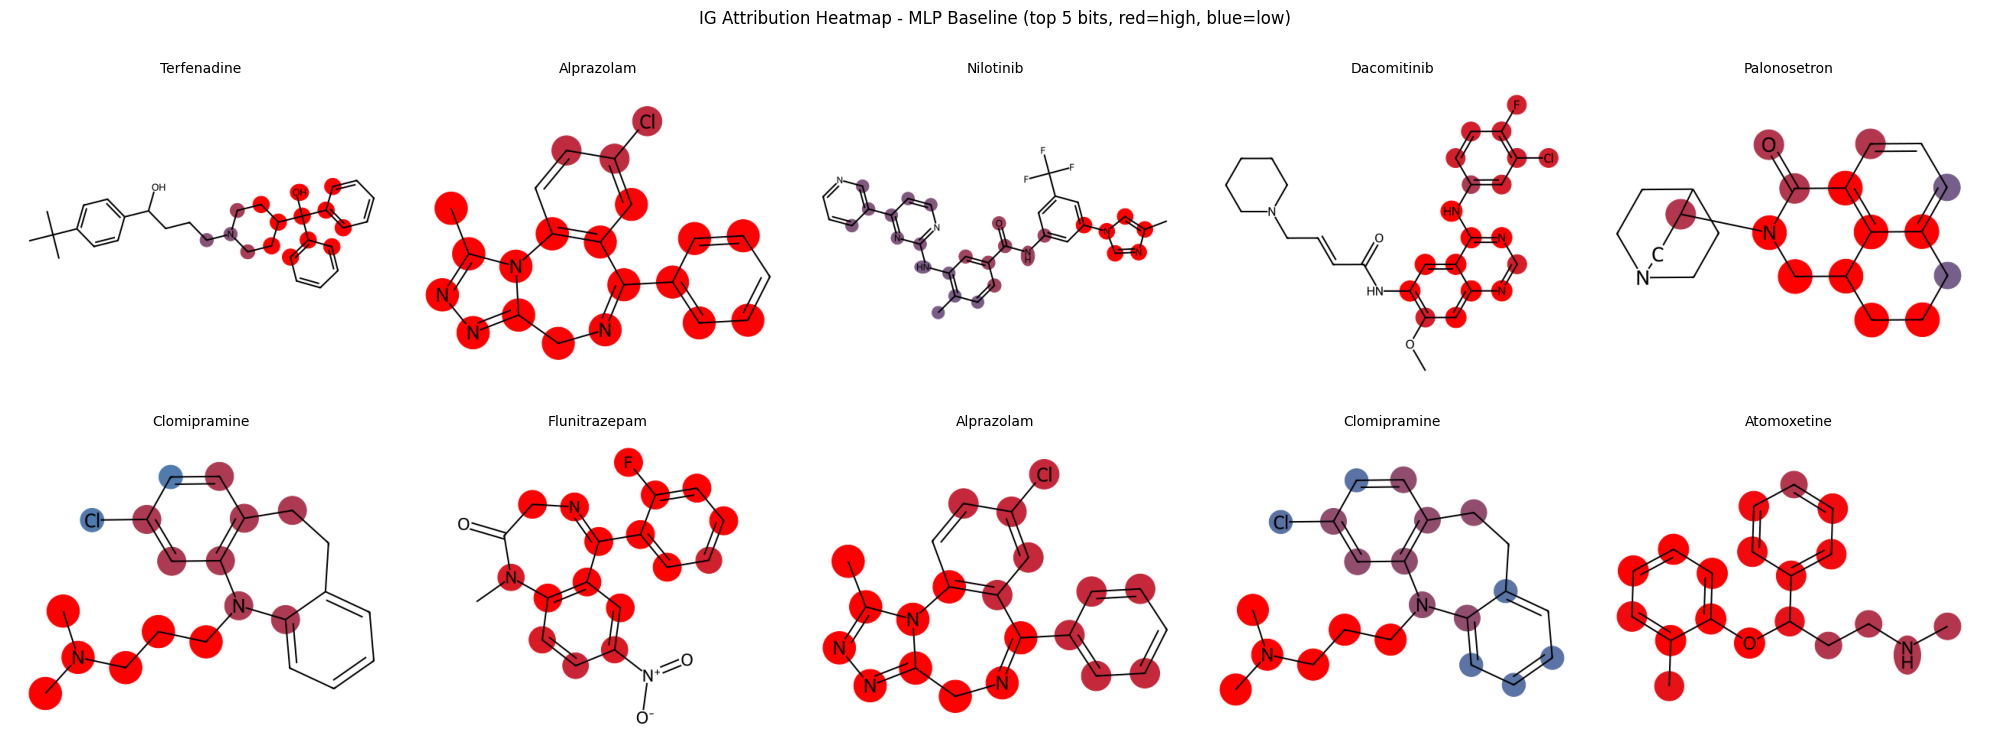

Saved to /content/drive/MyDrive/ddi_capstone/MLP_baseline/plots/ig_heatmap_grid_mlp.png


In [ ]:
# IG Attribution Heatmap — MLP Baseline
# =======================================
# Maps fingerprint bit attributions back to molecular substructures.
# Each Morgan bit corresponds to a circular neighborhood around an atom;
# atoms are colored by the maximum attribution of any bit that covers them.
# Red = high attribution (bit strongly influences prediction),
# Blue = low attribution (bit has little influence).
# Top-5 bits used for consistency with GAT notebook visualizations.

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io
RDLogger.DisableLog('rdApp.*')

# Load SMILES mapping
drug_mapping = pd.read_csv('/content/drive/MyDrive/ddi_capstone/molecular/data/drug_mapping_smiles.csv')
idx_to_smiles = dict(zip(drug_mapping['node idx'], drug_mapping['smiles']))
print(f"Drugs with SMILES: {sum(1 for v in idx_to_smiles.values() if pd.notna(v))}")


def draw_attribution_heatmap(smiles, drug_name, attributions, top_bits, save_path, top_k=5):
    """Draw molecule with atom-level color intensity based on IG attribution."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    bit_info = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048, bitInfo=bit_info)

    atom_weights = [0.0] * mol.GetNumAtoms()

    for bit in top_bits[:top_k]:
        bit_idx = bit.item()
        attr_value = abs(attributions[bit_idx].item())
        if bit_idx in bit_info:
            for atom_idx, radius in bit_info[bit_idx]:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
                atoms_in_env = set([atom_idx])
                for bond_idx in env:
                    bond = mol.GetBondWithIdx(bond_idx)
                    atoms_in_env.add(bond.GetBeginAtomIdx())
                    atoms_in_env.add(bond.GetEndAtomIdx())
                for a in atoms_in_env:
                    atom_weights[a] = max(atom_weights[a], attr_value)

    max_w = max(atom_weights) if max(atom_weights) > 0 else 1.0
    atom_weights = [w / max_w for w in atom_weights]

    # Red (high) -> Light blue (low)
    atom_colors = {}
    for i, w in enumerate(atom_weights):
        if w > 0.01:
            r = w
            g = 0.7 * (1 - w)
            b = 1.0 * (1 - w)
            atom_colors[i] = (r, g, b)

    highlight_atoms = [i for i, w in enumerate(atom_weights) if w > 0.01]
    highlight_radii = {i: 0.3 + atom_weights[i] * 0.2 for i in highlight_atoms}

    drawer = rdMolDraw2D.MolDraw2DCairo(500, 400)
    drawer.drawOptions().useBWAtomPalette()
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_colors,
        highlightAtomRadii=highlight_radii,
        highlightBonds=[]
    )
    drawer.FinishDrawing()

    png_data = drawer.GetDrawingText()
    img = Image.open(io.BytesIO(png_data))
    img.save(save_path)
    return img


# Generate heatmaps for all drugs in all pairs
heatmap_images = []

for result in all_ig_results:
    for key in [('drug_a', 'id_a', 'attr_a', 'top_bits_a'), ('drug_b', 'id_b', 'attr_b', 'top_bits_b')]:
        name = result[key[0]]
        nid = result[key[1]]
        attr = result[key[2]]
        bits = result[key[3]]

        smiles = idx_to_smiles.get(nid)
        if smiles is None or pd.isna(smiles):
            print(f"{name}: No SMILES, skipping")
            continue

        save_path = f'{plot_dir}/{name.lower()}_heatmap.png'
        img = draw_attribution_heatmap(smiles, name, attr, bits, save_path)
        if img:
            heatmap_images.append((name, img))
            print(f"{name}: saved")
        else:
            print(f"{name}: invalid SMILES")

# Display grid
if heatmap_images:
    n_imgs = len(heatmap_images)
    cols = min(5, n_imgs)
    rows = (n_imgs + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes_flat = np.array(axes).flatten()

    for i, (name, img) in enumerate(heatmap_images):
        axes_flat[i].imshow(img)
        axes_flat[i].set_title(name, fontsize=10)
        axes_flat[i].axis('off')

    for j in range(len(heatmap_images), len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle('IG Attribution Heatmap - MLP Baseline (top 5 bits, red=high, blue=low)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{plot_dir}/ig_heatmap_grid_mlp.png', dpi=150)
    plt.show()
    print(f"Saved to {plot_dir}/ig_heatmap_grid_mlp.png")

# MPL Baseline - Summary

## Test Results

| Metric | Value |
|---|---|
| AUC-ROC | 0.9693 |
| Hits@20 | 0.0803 |
| Precision | 0.9391 |
| Recall | 0.8594 |
| F1-Score | 0.8975 |
| Parameters | 295,425 |

## Biological Validation (top 200 test pairs vs 200 random, Fisher's exact test)

| Entity Type | Predicted | Random | Odds Ratio | p-value |
|---|---|---|---|---|
| Enzymes | 41/59 (69.5%) | 8/25 (32.0%) | 4.84 | 0.0016 |
| Targets | 12/200 (6.0%) | 4/99 (4.0%) | 1.52 | 0.3408 |
| Transporters | 18/25 (72.0%) | 4/7 (57.1%) | 1.93 | 0.3756 |

## EXAI Case Studies (5 pairs from top predictions)

| Drug Pair | Prediction | Shared Enzymes | Shared Targets |
|---|---|---|---|
| Terfenadine + Alprazolam | 90.8% | CYP3A4, CYP3A5, CYP3A7 | — |
| Nilotinib + Dacomitinib | 90.8% | CYP2C9, CYP2D6, CYP3A4 | — |
| Palonosetron + Clomipramine | 90.8% | CYP1A2, CYP2D6, CYP3A4 | — |
| Flunitrazepam + Alprazolam | 90.8% | CYP2C9, CYP3A4 | GABA(A) Receptor, Translocator protein |
| Clomipramine + Atomoxetine | 90.8% | CYP2C19, CYP2D6 | Noradrenaline transporter, Serotonin transporter |

## Key Findings

The MLP baseline achieves 96.9% AUC using only molecular fingerprints, demonstrating that molecular structure encodes strong interaction signals. However, this model has no access to graph topology, so it cannot capture pathway-mediated interactions that emerge from drug neighborhood patterns.

Biological validation reveals statistically significant enzyme overlap (p=0.0016, OR=4.84) in top predicted pairs: 69.5% share at least one metabolic enzyme compared to 32.0% in random pairs. This confirms that fingerprints capture structural signals related to shared CYP metabolic pathways. Target and transporter overlap are not significant, indicating that molecular structure alone does not predict shared functional relationships.

Integrated Gradients attributions highlight pharmacologically relevant substructures including nitrogen-containing heterocycles, aromatic ring systems, and halogen substituents. Attributions are orders of magnitude larger than in GNN models because gradients flow directly through the encoder without dilution from message passing layers.

Deployment advantage: Unlike GNN models, the MLP can predict interactions for new drugs outside the training graph. It only needs a SMILES string to generate a fingerprint, making it suitable for screening novel compounds.

## Files

Models: best_model.pt, training_history.json, test_results.json, ig_results.json, biological_validation.json, config.json

Plots: training_curves.png, test_evaluation.png, ig_heatmap_grid_mlp.png, individual drug heatmaps

In [ ]:
# Persist all results to Drive for cross-model comparison.
# Saves IG attributions, biological validation, and config as JSON
# so downstream notebooks (GraphSAGE, GAT) can load and compare.

ig_results_save = {}
for result in all_ig_results:
    ig_results_save[result['name']] = {
        'prediction': result['prediction'],
        'drug_a': result['drug_a'], 'drug_b': result['drug_b'],
        'id_a': result['id_a'], 'id_b': result['id_b'],
        'shared_enzymes': sorted(result['shared_enzymes']),
        'shared_targets': sorted(result['shared_targets']),
        'drug_a_top_bits': [int(b) for b in result['top_bits_a'][:10].tolist()],
        'drug_b_top_bits': [int(b) for b in result['top_bits_b'][:10].tolist()],
        'drug_a_top_values': [float(result['attr_a'][b].item()) for b in result['top_bits_a'][:10]],
        'drug_b_top_values': [float(result['attr_b'][b].item()) for b in result['top_bits_b'][:10]],
    }

bio_val_save = {}
for name, r in validation_results.items():
    bio_val_save[name] = {
        'pred_overlap': r['pred_overlap'],
        'pred_annotated': r['pred_annotated'],
        'pred_rate': r['pred_rate'],
        'rand_overlap': r['rand_overlap'],
        'rand_annotated': r['rand_annotated'],
        'rand_rate': r['rand_rate'],
        'odds_ratio': float(r['odds_ratio']) if not np.isnan(r['odds_ratio']) else None,
        'p_value': float(r['p_value']) if not np.isnan(r['p_value']) else None,
    }

try:
    with open(f'{save_dir}/ig_results.json', 'w') as f:
        json.dump(ig_results_save, f, indent=2)
    with open(f'{save_dir}/config.json', 'w') as f:
        json.dump(config, f, indent=2)
    with open(f'{save_dir}/biological_validation.json', 'w') as f:
        json.dump(bio_val_save, f, indent=2)

    print("Files saved:")
    for f_name in sorted(os.listdir(save_dir)):
        size = os.path.getsize(f'{save_dir}/{f_name}') / 1024
        print(f"  {f_name} ({size:.1f} KB)")

    print("\nPlots saved:")
    for f_name in sorted(os.listdir(plot_dir)):
        size = os.path.getsize(f'{plot_dir}/{f_name}') / 1024
        print(f"  {f_name} ({size:.1f} KB)")

except OSError as e:
    print(f"Warning: could not save results — {e}")

Files saved:
  best_model.pt (1158.1 KB)
  biological_validation.json (0.7 KB)
  config.json (0.2 KB)
  ig_results.json (6.1 KB)
  test_results.json (0.2 KB)
  training_history.json (2.9 KB)

Plots saved:
  alprazolam_heatmap.png (39.7 KB)
  amitriptyline_heatmap.png (31.4 KB)
  atomoxetine_heatmap.png (30.3 KB)
  chloroquine_heatmap.png (24.6 KB)
  clomipramine_heatmap.png (34.7 KB)
  dacomitinib_heatmap.png (27.3 KB)
  etizolam_heatmap.png (33.5 KB)
  etravirine_heatmap.png (29.4 KB)
  flunitrazepam_heatmap.png (31.3 KB)
  glasdegib_heatmap.png (33.6 KB)
  ig_heatmap_grid_mlp.png (598.6 KB)
  istradefylline_heatmap.png (31.1 KB)
  loratadine_heatmap.png (35.2 KB)
  nilotinib_heatmap.png (29.4 KB)
  palonosetron_heatmap.png (30.4 KB)
  prasugrel_heatmap.png (25.8 KB)
  ritonavir_heatmap.png (30.0 KB)
  siponimod_heatmap.png (23.7 KB)
  terfenadine_heatmap.png (21.7 KB)
  test_evaluation.png (117.2 KB)
  training_curves.png (132.4 KB)
